<a href="https://colab.research.google.com/github/manuel1729/Procesos-Estoc-sticos/blob/main/Tarea_1_Estocasticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Caminata aleatoria 1D**
Gómez Cruz Manuel

Una caminata aleatoria en el contexto de procesos estocásticos es una secuencia de variables aleatorias que describe el camino que toma un elemento que se mueve en pasos sucesivos, donde la dirección de cada paso es aleatoria. Es decir, la posición futura del elemento depende de su posición actual y de un componente aleatorio.

Con probabilidad p de ir a la derecha y q en ir a la izquierda tal que p+q=1

1. Importamos librerías para importar variables aleatorias, numpy paa agregarlo en lista y la última para graficar.

In [24]:
import random as rd
import numpy as np
import matplotlib.pyplot as plt

2. Hacemos la función para agregarla enla lista.

In [25]:
def caminata(n,p):
  posicion = 0
  camino = [posicion]
  for _ in range(n):
    if rd.random() < p:
      posicion += 1
    else:
      posicion -= 1
    camino.append(posicion)
  return np.array(camino)

3. Llamamos la función y imprimimos los valores.

In [26]:
caminata(100,0.5)

array([  0,  -1,   0,  -1,  -2,  -3,  -2,  -1,   0,  -1,   0,   1,   0,
         1,   0,  -1,   0,   1,   2,   3,   4,   3,   2,   3,   2,   3,
         2,   3,   2,   3,   4,   3,   2,   3,   4,   3,   4,   3,   4,
         3,   2,   3,   4,   5,   4,   5,   6,   5,   6,   7,   8,   7,
         6,   5,   4,   3,   2,   1,   2,   3,   4,   3,   2,   3,   2,
         1,   2,   1,   2,   1,   0,   1,   0,  -1,  -2,  -3,  -4,  -5,
        -4,  -5,  -6,  -7,  -8,  -9,  -8,  -9,  -8,  -9,  -8,  -9,  -8,
        -9, -10,  -9,  -8,  -9, -10,  -9,  -8,  -9, -10])

4. Graficamos y podemos cambiar el valor de p y n.

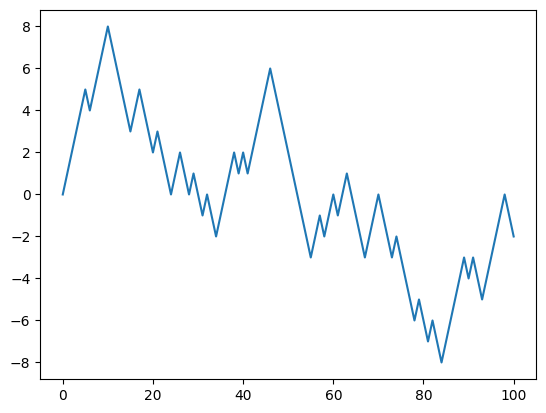

In [27]:
plt.plot(caminata(100,0.5))
#

## Análisis y conclusiones


1. ¿Qué debe pasar con p para poder pasar al origen?

### Investigamos el Efecto de 'p' en el Drift

Modificar el valor de 'p' en la función `caminata` (ej., 0.2, 0.5, 0.8) y graficar múltiples caminatas para observar cómo la probabilidad de movimiento influye en la dirección general de la caminata a lo largo del tiempo. Calculamos y comparamos la posición final promedio.


Creamos la función para algún valor p del que probaremos uno cercano a la derecha, a la izquierda y uno intermedio entre [0.2,0.5,0.8] y el número de simulaciones a realizar para la media de la posició final y su desviación estandar

In [28]:
def analizar_caminata(p, n_pasos, num_simulaciones):
    posiciones_final = []
    paths_to_plot = []

    for i in range(num_simulaciones):
        c = caminata(n_steps, p)
        posiciones_final.append(c[-1])
        paths_to_plot.append(c)

    media_final_pos = np.mean(posiciones_final)

    return media_final_pos, posiciones_final, paths_to_plot

*   **Cuando `p = 0.2` (Probabilidad de ir a la derecha es baja):**
    *   Como se observa en el gráfico para `p=0.2`, la mayoría de las caminatas muestran una clara tendencia a moverse hacia la izquierda. Las trayectorias se inclinan negativamente.

In [29]:
# Ejemplo de uso con un solo valor de p
p1 = 0.2
pasos1 = 100
simulaciones1= 1000

# Llamar a la función
media_final_pos1, pos_final1, grafica1 = analizar_caminata(p1, pasos1, simulaciones1)

In [30]:
print(f"Media de la posición final p={p1}: {media_final_pos1:.2f}")
print(f"Desvación estandar: {np.std(pos_final1):.2f}")

Media de la posición final p=0.2: -60.16
Desvación estandar: 7.74


* Este valor negativo y significativo confirma que cuando la probabilidad de moverse a la izquierda (`q = 1 - p = 0.8`) es mayor que la de moverse a la derecha, la caminata tiende a alejarse del origen en dirección negativa.

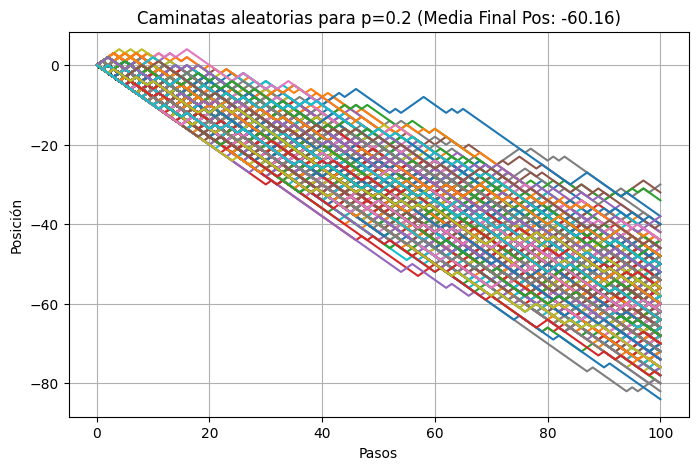

In [31]:
# Graficar los resultados
plt.figure(figsize=(8, 5))

for path in grafica1:
    plt.plot(path)

plt.title(f'Caminatas aleatorias para p={p1} (Media Final Pos: {media_final_pos1:.2f})')
plt.xlabel('Pasos')
plt.ylabel('Posición')
plt.grid(True)
plt.show()

*   **Cuando `p = 0.5` (Probabilidad de ir a la derecha es igual a la de ir a la izquierda):**
    *   El gráfico para `p=0.5` muestra que las caminatas no tienen una dirección preferente. Las trayectorias oscilan alrededor del origen, a veces moviéndose hacia la derecha y otras hacia la izquierda. Hay una mayor dispersión pero sin un drift claro.

In [32]:
# Ejemplo de uso con un solo valor de p
p = 0.5
pasos = 100
simulaciones = 1000

# Llamar a la función
media_final_pos, pos_final, grafica = analizar_caminata(p, pasos, simulaciones)

In [33]:
print(f"Media de la posición final p={p}: {media_final_pos:.2f}")
print(f"Desvación estandar: {np.std(pos_final):.2f}")

Media de la posición final p=0.5: 0.07
Desvación estandar: 9.72


*  Un valor cercano a cero indica que, a largo plazo y en promedio, la caminata no tiende a desviarse significativamente del origen. Esto es lo esperado en una caminata aleatoria simétrica.

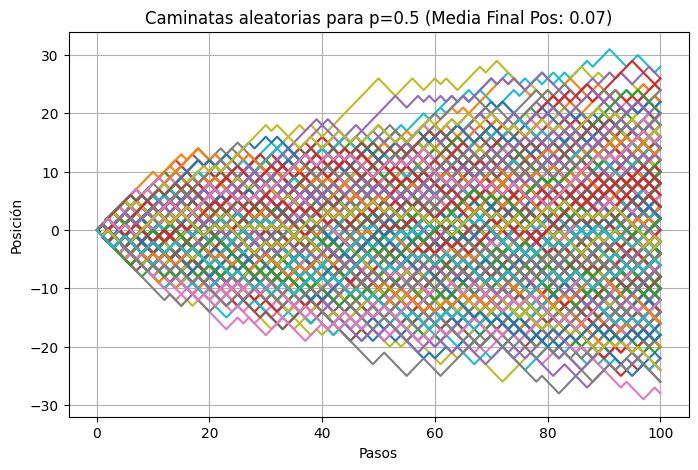

In [34]:
# Graficar los resultados
plt.figure(figsize=(8, 5))

for path in grafica:
    plt.plot(path)

plt.title(f'Caminatas aleatorias para p={p} (Media Final Pos: {media_final_pos:.2f})')
plt.xlabel('Pasos')
plt.ylabel('Posición')
plt.grid(True)
plt.show()

*   **Cuando `p = 0.8` (Probabilidad de ir a la derecha es alta):**
    *   En el gráfico para `p=0.8`, se observa que las caminatas tienen una fuerte tendencia a moverse hacia la derecha, con trayectorias inclinadas positivamente.

In [35]:
# Ejemplo de uso con un solo valor de p
p2 = 0.8
pasos2= 100
simulaciones2 = 1000

# Llamar a la función
media_final_pos2, pos_final2, grafica2 = analizar_caminata(p2, pasos2, simulaciones2)

In [36]:
print(f"Media de la posición final p={p}: {media_final_pos2:.2f}")
print(f"Desvación estandar: {np.std(pos_final2):.2f}")

Media de la posición final p=0.5: 60.31
Desvación estandar: 7.92


Este valor positivo y significativo demuestra que una mayor probabilidad de moverse a la derecha (`p`) resulta en un drift positivo y una posición final promedio alejada del origen en dirección positiva.

**Conclusión:**

El valor de `p` tiene un impacto directo y predecible en el drift y la posición final promedio de la caminata aleatoria. Si `p > 0.5`, la caminata tiene un drift positivo (se mueve a la derecha). Si `p < 0.5`, la caminata tiene un drift negativo (se mueve a la izquierda). Si `p = 0.5`, la caminata es simétrica y no presenta un drift discernible, con una posición final promedio cercana a cero, aunque la dispersión de las posiciones finales individuales puede ser considerable. Este comportamiento ilustra cómo una pequeña asimetría en las probabilidades de movimiento puede llevar a una dirección preferencial y un desplazamiento significativo a largo plazo.

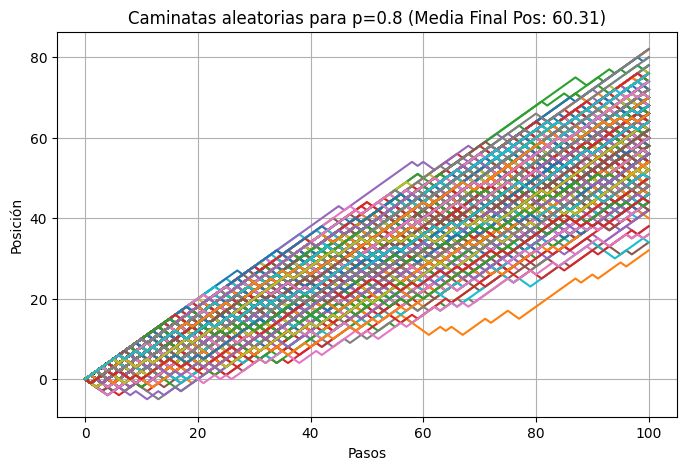

In [37]:
# Graficar los resultados
plt.figure(figsize=(8, 5))

for path in grafica2:
    plt.plot(path)

plt.title(f'Caminatas aleatorias para p={p2} (Media Final Pos: {media_final_pos2:.2f})')
plt.xlabel('Pasos')
plt.ylabel('Posición')
plt.grid(True)
plt.show()

## Analizar la Dispersión con 'n' creciente

Simular varias caminatas con diferentes números de pasos 'n' (ej., 50, 100, 500) manteniendo 'p' constante (ej., 0.5). Graficamos los resultados y calculamos la varianza de las posiciones finales para cada 'n' para entender cómo la dispersión aumenta con el tiempo.


In [44]:
n_valores = [50, 100, 500]
p = 0.5
num_simu = 1000

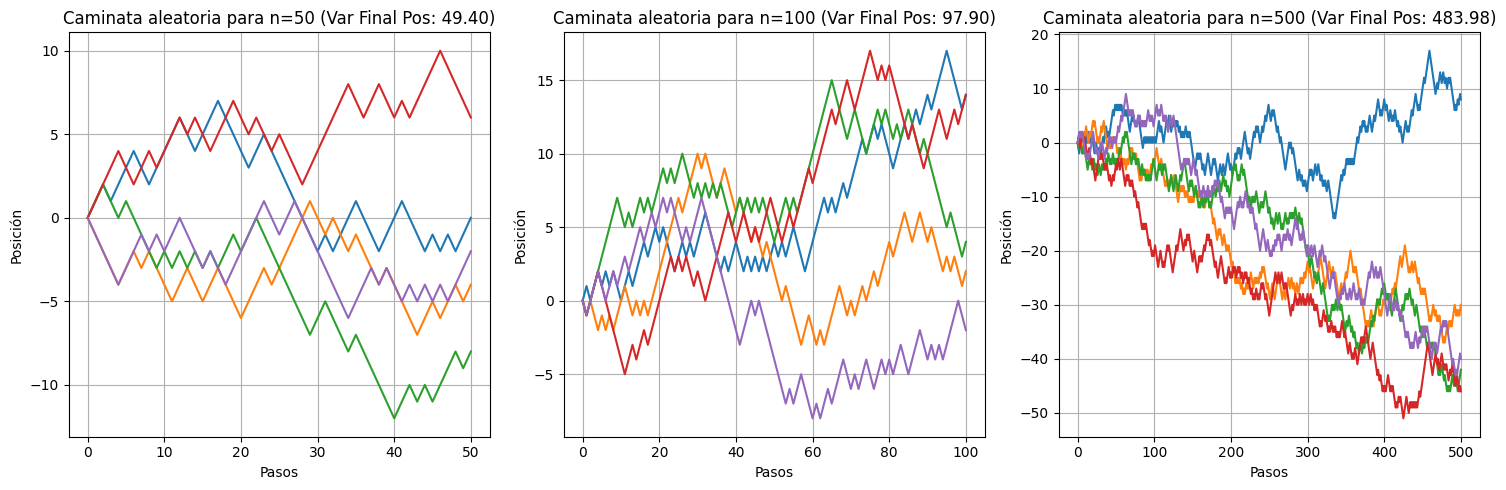

Varianzas al finalizar posición:
n=50: 49.40
n=100: 97.90
n=500: 483.98


In [55]:
var_final_pos = {}

plt.figure(figsize=(15, 5))

for n_val in n_valores:
    final_pos = []
    fig= []

    for i in range(num_simu):
        cam = caminata(n_val, p)
        final_pos.append(cam[-1])
        if i < 5:
            fig.append(cam)

    var = np.var(final_pos)
    var_final_pos[n_val] = var

    plt.subplot(1, len(n_valores), list(n_valores).index(n_val) + 1)
    for path in fig:
        plt.plot(path)
    plt.title(f'Caminata aleatoria para n={n_val} (Var Final Pos: {var:.2f})')
    plt.xlabel('Pasos')
    plt.ylabel('Posición')
    plt.grid(True)

plt.tight_layout()
plt.show()

print("Varianzas al finalizar posición:")
for n_val, variance in var_final_pos.items():
    print(f"n={n_val}: {variance:.2f}")



Los resultados de las simulaciones para diferentes números de pasos `n` demuestran claramente cómo la dispersión de la caminata aleatoria aumenta con el tiempo, manteniendo la probabilidad `p = 0.5` (caminata simétrica).

*   **Cuando `n = 50` (50 pasos):**
    *   El gráfico muestra caminatas que se extienden relativamente cerca del origen. Las trayectorias son más cortas y, por lo tanto, las posiciones finales están menos dispersas.

*   **Cuando `n = 100` (100 pasos):**
    *   Con el doble de pasos, las caminatas en el gráfico se extienden más lejos del origen. Las trayectorias individuales muestran una mayor libertad para desviarse, aunque aún oscilan en torno a cero en promedio.

*   **Cuando `n = 500` (500 pasos):**
    *   En este caso, las caminatas exhiben una dispersión significativamente mayor. Las trayectorias se alejan mucho más del origen, explorando un rango mucho más amplio de posiciones.
